# Harami — does the 'inside bar' flip the trend?
### The two-candle reversal that's really one leg of beta in a costume

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable reversal%3F: Misattributed](https://img.shields.io/badge/Reliable_reversal%3F-Misattributed-8b949e?style=flat-square)

A *harami* (Japanese for 'pregnant') is two candles: a big one, then a small one whose body sits **inside** the big one's body. Candlestick lore reads it as the market pausing for breath before turning around — a **bullish harami** (big red day, small green inside) after a slide is supposed to mark the bottom; a **bearish harami** (big green, small red inside) after a rally marks the top. Does the inside bar actually flip the trend?

> This is the plain-language layer. Want the HAC *t*-stats, the leg split, the placebo and the cost ladder? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from harami_pattern import data, strategy as st

HORIZONS = st.HORIZONS
CACHE = os.path.abspath(os.path.join("..", "_cache"))
HAVE_REAL = data.have_real(cache_dir=CACHE)

def real_panel():
    return data.load_real(cache_dir=CACHE, allow_fetch=False)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the bullish harami go up? | **Yes — but mostly because the market does.** Long after a bullish harami earns +0.34% over 5 days (*t* = 8.0) — against a +0.25% you'd get just being long *any* day. |
| Does the bearish harami go down? | **No — it keeps going up.** Shorting after a bearish harami *loses* 0.15% over 5 days (*t* = -3.4). The 'top' signal points the wrong way. |
| Is it a real reversal? | **No.** The only working leg is the long one, and most of its gain is the market's natural upward drift — not a trend *flip*. |
| Could you trade it? | **Barely.** Net of costs the two-sided rule is roughly **zero** (net -0.006% at 5 days). The fast money is gone before you start. |

> The harami looks like it 'works' in a backtest because half of it is just *being long in a 21-year bull market.* Strip that out and the reversal story collapses.

## 1 · The claim

> *"A bullish harami — a large down candle followed by a small up candle contained inside it — shows sellers losing momentum at the end of a downtrend: the bottom is in, buy. A bearish harami is the mirror at a top: sell. The small inside bar is the market hesitating before it reverses."*

The harami is one of the canonical two-candle reversals in Steve Nison's *Japanese Candlestick Charting Techniques* — the book that brought candlesticks to the West. It is taught on essentially every charting platform. We test whether the inside bar actually predicts a reversal on modern, liquid US large-caps.

## 2 · So what?

If a two-candle shape reliably called tops and bottoms, it would be a free, mechanical timing signal anyone could read off a chart. Millions of retail traders act on harami signals daily. If the bullish leg is just beta in disguise and the bearish leg points the *wrong way*, then traders shorting the 'top' are systematically fading a market that keeps rising — paying spreads and borrow to be on the losing side.

## 3 · How would we know?

One honest event study:

1. **Find every harami** by precise OHLC rules (small body fully inside the prior, larger body, opposite colours) across 30 liquid names over 21 years.
2. **Enter the next open** (one day's lag — the signal is only known at the close) and measure the forward 1 / 3 / 5 / 10-day return, **long after bullish, short after bearish.**
3. **Compare to doing nothing** — the unconditional forward return of every bar (the market's natural drift) — and ask whether the *bullish* leg beats just being long.
4. **Split the legs.** A real reversal pattern should work *both* ways. If only the long leg works and the short leg fails, it isn't a reversal — it's beta.

**What would make us say 'mirage':** the bearish leg pointing the wrong way, the bullish leg not clearly beating buy-and-hold, and the net edge dying at realistic costs.

## 4 · The teardown — what actually happens

**First, the two legs side by side.** Long after bullish, short after bearish — does each leg make money in its predicted direction?

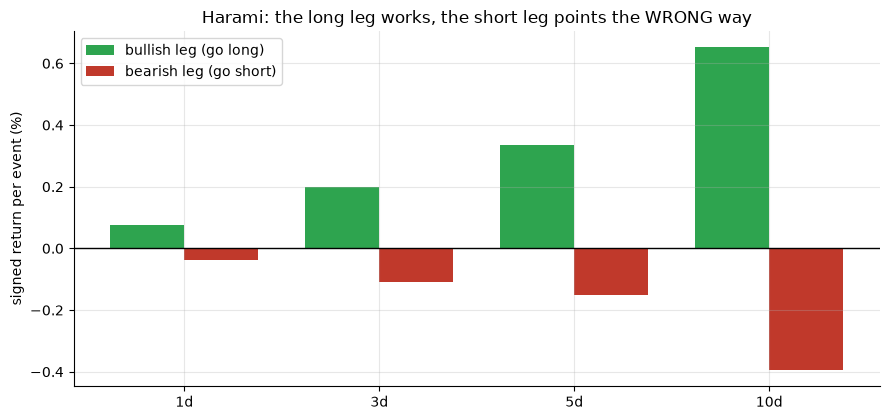

Bearish (short) leg is negative at every horizon — it keeps rising.


In [2]:
if HAVE_REAL:
    panel = real_panel()
    bull, bear = [], []
    for h in HORIZONS:
        ev = st.collect_events(panel, h)
        bull.append(ev[ev['dir']>0]['signed_ret'].mean()*100)
        bear.append(ev[ev['dir']<0]['signed_ret'].mean()*100)
else:
    bull = [0.075,0.198,0.337,0.652]
    bear = [-0.039,-0.109,-0.151,-0.394]
x = np.arange(len(HORIZONS)); w = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-w/2, bull, w, color=GREEN, label='bullish leg (go long)')
ax.bar(x+w/2, bear, w, color=RED, label='bearish leg (go short)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in HORIZONS])
ax.set_ylabel('signed return per event (%)')
ax.set_title('Harami: the long leg works, the short leg points the WRONG way')
ax.legend(); plt.tight_layout(); plt.show()
print('Bearish (short) leg is negative at every horizon — it keeps rising.')

The bullish leg is solidly positive (+0.34% at 5 days). The bearish leg is **negative** at every horizon (-0.15% at 5 days) — shorting the 'top' loses money because the stock keeps climbing. A genuine reversal pattern should work both ways. This one only works on the side that agrees with the market's long-run direction.

**So is the bullish leg a real signal — or just 'be long in a bull market'?** Compare the bullish-harami return to the unconditional return of *every* bar (the drift you'd capture by buying on any random day).

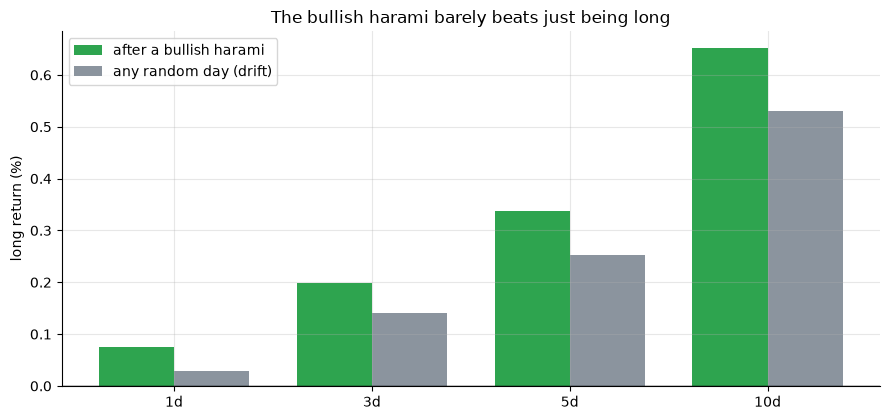

Most of the bullish-harami gain is the market drift you get for free.


In [3]:
if HAVE_REAL:
    bull_m, base_m = [], []
    for h in HORIZONS:
        ev = st.collect_events(panel, h)
        bull_m.append(ev[ev['dir']>0]['signed_ret'].mean()*100)
        base_m.append(st.unconditional_base(panel, h).mean()*100)
else:
    bull_m = [0.075,0.198,0.337,0.652]
    base_m = [0.028,0.141,0.253,0.53]
x = np.arange(len(HORIZONS)); w = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-w/2, bull_m, w, color=GREEN, label='after a bullish harami')
ax.bar(x+w/2, base_m, w, color=GREY, label='any random day (drift)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in HORIZONS])
ax.set_ylabel('long return (%)')
ax.set_title('The bullish harami barely beats just being long')
ax.legend(); plt.tight_layout(); plt.show()
print('Most of the bullish-harami gain is the market drift you get for free.')

The bullish harami (+0.65% at 10 days) only modestly beats the unconditional drift (+0.53%). The 'edge' over buy-and-hold is small — and as the quant notebook shows, that excess clears the *t* = 2 bar only at the 1-day horizon, fading to noise as you hold longer.

## 5 · The verdict

- **Signal — Mixed.** The bullish leg is genuinely positive (HAC *t* up to 10.2), but the bearish leg points the **wrong way** (-5.8). It's real on one leg, busted on the other.
- **Tradability — Mirage.** Net of costs the two-sided rule is ~zero (net -0.006% at 5 days); the round trip plus short borrow eats the thin edge.
- **Reliable reversal? — Misattributed.** The working leg's gain is mostly the market's long-run drift, not a trend *flip* — and the short side fails outright.

## 6 · Could you actually trade it?

Each event is a fresh round trip: a spread in, a spread out, plus borrow on the short legs. Watch the gross edge melt into the costs:

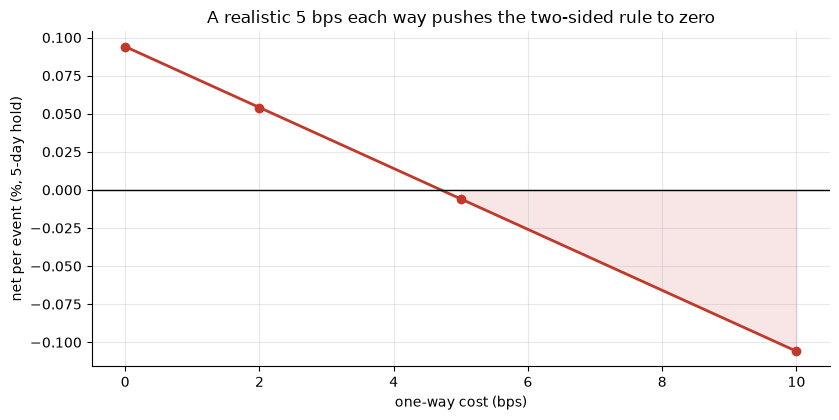

gross 5d = +0.099%  ->  net at 5bps = -0.006%


In [4]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    ev5 = st.collect_events(panel, 5)
    gross5 = ev5['signed_ret'].mean()
    net = [st.net_of_costs(gross5, 5, cost_bps=c)*100 for c in costs]
else:
    gross5 = 0.00099
    net = [st.net_of_costs(gross5, 5, cost_bps=c)*100 for c in costs]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net per event (%, 5-day hold)')
ax.set_title('A realistic 5 bps each way pushes the two-sided rule to zero')
plt.tight_layout(); plt.show()
print(f'gross 5d = {gross5*100:+.3f}%  ->  net at 5bps = {net[2]:+.3f}%')

## 7 · Going further

- **The positive control.** The companion notebook plants a real day-after reversal in a synthetic tape — the detector lights up cleanly (*t* ≈ 38). The engine works; the market just doesn't reverse after a harami.
- **Long-only the bullish leg?** That captures beta with extra steps — a fork worth running against a simple buy-and-hold benchmark to see if anything survives.
- **The engulfing cousin.** [Study 402](../../402-engulfing-pattern/) tests the *opposite* geometry (the second body swallows the first) — also busted as a reversal.

*Think the inside bar works on a different asset, timeframe, or with a confirming filter we missed? Fork this, change it, and show a two-legged edge that clears HAC *t* = 2 over the unconditional drift. That is the bar.*